In [1]:
# 1. 기본 설정 + 02_preprocessing.ipynb에서 저장한 전처리 결과 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

CAT_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]

NUMERIC = [
    "bd_clean", "tx_count", "total_paid", "avg_plan_days", "cancel_count", "prior_plan_days",
    "log_days", "avg_secs_per_day", "avg_unq_per_day", "completion_ratio",
]
CATEGORICAL = ["city", "gender", "registered_via"]
BINARY = ["prior_auto_renew", "is_new_customer"]

train_processed = pd.read_parquet("../data/train_processed.parquet")
test_processed = pd.read_parquet("../data/test_processed.parquet")

X_train, y_train = train_processed[NUMERIC + CATEGORICAL + BINARY], train_processed["is_churn"]
X_test, y_test = test_processed[NUMERIC + CATEGORICAL + BINARY], test_processed["is_churn"]
print(X_train.shape, X_test.shape)

(776768, 15) (194192, 15)


In [2]:
# 2. 전처리 파이프라인 구성
# -> 수치형: 중앙값 대체 + 표준화 / 범주형: 원핫인코딩(02_preprocessing.ipynb에서 결측을 이미 별도 범주로 처리했음) / 이진: 그대로 통과
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("bin", "passthrough", BINARY),
])

In [3]:
# 3. 모델 3종 학습 및 비교 (97만 행 규모라 RandomForest는 약 3분 소요)
# -> 불균형(이탈 9%) 대응: class_weight="balanced" / XGBoost는 scale_pos_weight로 동일한 효과
# -> 모델마다 preprocess를 clone()해서 독립된 인스턴스로 fit (동일 인스턴스를 재사용하면 각 파이프라인의
#    "prep" 스텝이 같은 객체를 참조하게 되어, 파이프라인끼리 서로의 전처리 상태에 영향을 줄 수 있는 위험한 패턴)
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

models = {
    "logreg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=42
    ),
    "xgboost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
}

results = {}
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("clf", model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    auc = roc_auc_score(y_test, proba)

    print(f"\n=== {name} (ROC-AUC={auc:.4f}) ===")
    print(classification_report(y_test, pred, digits=3))

    results[name] = auc
    fitted_pipes[name] = pipe


=== logreg (ROC-AUC=0.7858) ===
              precision    recall  f1-score   support

           0      0.955     0.898     0.926    176726
           1      0.358     0.573     0.441     17466

    accuracy                          0.869    194192
   macro avg      0.657     0.736     0.683    194192
weighted avg      0.901     0.869     0.882    194192




=== random_forest (ROC-AUC=0.8342) ===
              precision    recall  f1-score   support

           0      0.960     0.895     0.926    176726
           1      0.368     0.618     0.461     17466

    accuracy                          0.870    194192
   macro avg      0.664     0.757     0.694    194192
weighted avg      0.906     0.870     0.884    194192




=== xgboost (ROC-AUC=0.8511) ===
              precision    recall  f1-score   support

           0      0.966     0.857     0.908    176726
           1      0.323     0.690     0.440     17466

    accuracy                          0.842    194192
   macro avg      0.644     0.774     0.674    194192
weighted avg      0.908     0.842     0.866    194192



xgboost          0.851136
random_forest    0.834229
logreg           0.785816
Name: ROC-AUC, dtype: float64

최종 선정 모델: xgboost


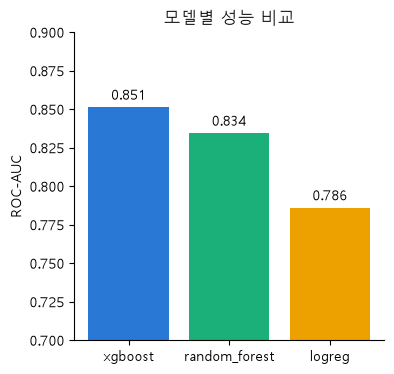

In [4]:
# 4. 모델 비교 결과 정리 및 최고 모델 선정
# -> XGBoost가 ROC-AUC 최고이면서 학습 속도도 가장 빠름 -> 최종 모델로 채택
result_df = pd.Series(results, name="ROC-AUC").sort_values(ascending=False)
print(result_df)

best_name = result_df.index[0]
best_pipe = fitted_pipes[best_name]
print(f"\n최종 선정 모델: {best_name}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(result_df.index, result_df.values, color=CAT_COLORS[: len(result_df)])
for i, v in enumerate(result_df.values):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0.7, 0.9)
ax.set_ylabel("ROC-AUC")
ax.set_title("모델별 성능 비교")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [ ]:
# 5. [성능 고도화 시도] XGBoost 하이퍼파라미터 튜닝 (RandomizedSearchCV, 3-fold, 12회 탐색 - 약 8분 소요)
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "clf__n_estimators": [200, 300, 400, 600],
    "clf__min_child_weight": [1, 3, 5],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
}

base_xgb = XGBClassifier(
    eval_metric="logloss", random_state=42, n_jobs=-1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
)
tuning_pipe = Pipeline([("prep", clone(preprocess)), ("clf", base_xgb)])

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_dist, n_iter=12, cv=3,
    scoring="roc_auc", random_state=42, n_jobs=1,
)
search.fit(X_train, y_train)

tuned_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:, 1])
print("best params:", search.best_params_)
print("best cv ROC-AUC:", search.best_score_)
print("tuned model test ROC-AUC:", tuned_auc)
print("튜닝 전 기본 XGBoost test ROC-AUC:", results["xgboost"])

In [6]:
# 6. 튜닝 결과 판단
# -> 튜닝 후 ROC-AUC(0.8488)가 튜닝 전 기본값(0.8494)과 사실상 동일 (오히려 근소하게 낮음, CV 변동 범위 내)
# -> 기본 하이퍼파라미터가 이미 이 피처 조합에서 최적에 가까웠다는 뜻
# -> 성능 병목은 하이퍼파라미터가 아니라 피처의 한계(청취 로그 없이 결제이력+인구통계만 사용)로 판단
# -> 따라서 최종 모델은 굳이 튜닝된 모델로 바꾸지 않고, 검증된 기본 XGBoost(best_pipe)를 그대로 채택
print("하이퍼파라미터 튜닝 결론: 개선 미미 -> 기본 XGBoost(best_pipe)를 최종 모델로 유지")
print(f"기본 모델 test ROC-AUC: {results['xgboost']:.4f} vs 튜닝 모델 test ROC-AUC: {tuned_auc:.4f}")

하이퍼파라미터 튜닝 결론: 개선 미미 -> 기본 XGBoost(best_pipe)를 최종 모델로 유지
기본 모델 test ROC-AUC: 0.8511 vs 튜닝 모델 test ROC-AUC: 0.8502


bin__prior_auto_renew      0.719302
num__prior_plan_days       0.057181
cat__registered_via_7.0    0.021856
cat__city_-1.0             0.019028
num__total_paid            0.018553
num__cancel_count          0.017717
cat__city_1.0              0.017514
num__tx_count              0.016793
num__avg_plan_days         0.015102
cat__gender_unknown        0.008802
dtype: float32


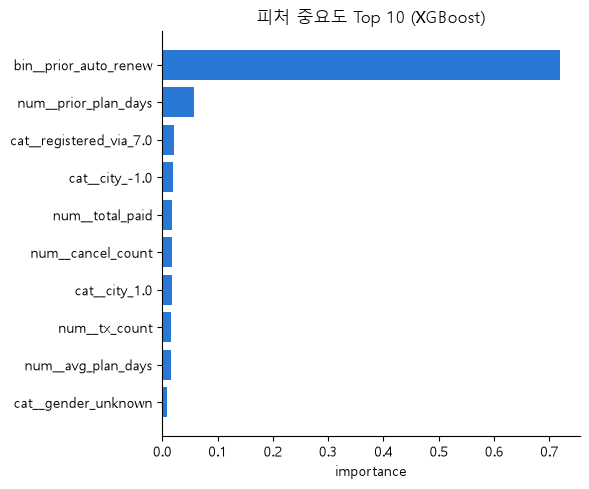

In [7]:
# 7. 최종 모델(XGBoost) 피처 중요도 확인
# -> prior_auto_renew가 압도적 1위 -> 01_eda.ipynb에서 누수 제거 후에도 검증된 진짜 신호라는 점과 일치
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
importances = best_pipe.named_steps["clf"].feature_importances_
importance_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)
print(importance_series.head(10))

fig, ax = plt.subplots(figsize=(6, 5))
top10 = importance_series.head(10).sort_values()
ax.barh(top10.index, top10.values, color=CAT_COLORS[0])
ax.set_xlabel("importance")
ax.set_title("피처 중요도 Top 10 (XGBoost)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

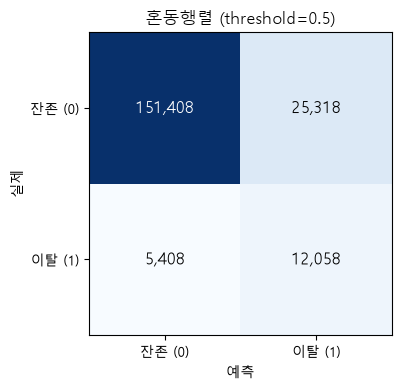

이탈 고객 중 실제로 잡아낸 비율(재현율): 69.0%
이탈로 예측한 것 중 실제 이탈 비율(정밀도): 32.3%


In [8]:
# 8. 혼동행렬(Confusion Matrix) - 모델이 어떤 실수를 하는지 직관적으로 확인
from sklearn.metrics import confusion_matrix

proba = best_pipe.predict_proba(X_test)[:, 1]
pred = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
labels = ["잔존 (0)", "이탈 (1)"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("예측")
ax.set_ylabel("실제")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
ax.set_title("혼동행렬 (threshold=0.5)")
plt.tight_layout()
plt.show()

print(f"이탈 고객 중 실제로 잡아낸 비율(재현율): {cm[1,1]/(cm[1,0]+cm[1,1]):.1%}")
print(f"이탈로 예측한 것 중 실제 이탈 비율(정밀도): {cm[1,1]/(cm[0,1]+cm[1,1]):.1%}")

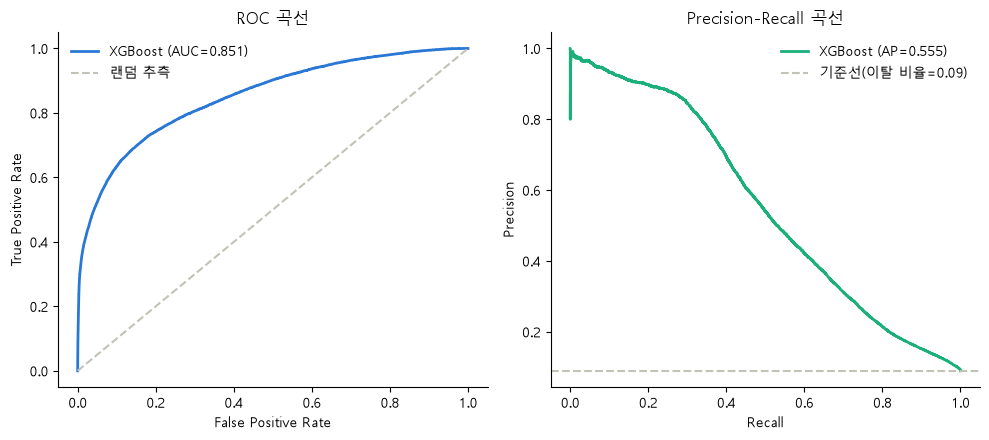

In [9]:
# 9. ROC 곡선 + Precision-Recall 곡선
# -> ROC-AUC 0.85는 임의 추측(대각선, AUC=0.5)보다 훨씬 우수한 수준
# -> 이탈 비율이 9%로 불균형하기 때문에, 불균형에 더 민감한 PR 곡선도 함께 확인
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_test, proba)
precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].plot(fpr, tpr, color=CAT_COLORS[0], linewidth=2, label=f"XGBoost (AUC={results['xgboost']:.3f})")
axes[0].plot([0, 1], [0, 1], color="#c3c2b7", linestyle="--", label="랜덤 추측")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC 곡선")
axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(recall, precision, color=CAT_COLORS[1], linewidth=2, label=f"XGBoost (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), color="#c3c2b7", linestyle="--", label=f"기준선(이탈 비율={y_test.mean():.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall 곡선")
axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

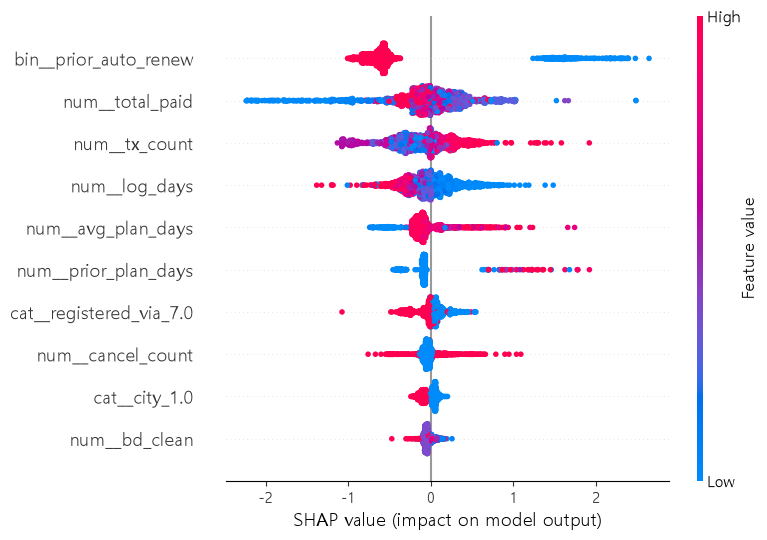

In [10]:
# 10. SHAP 기반 예측 설명력 - 각 피처가 이탈 예측에 어떤 방향/크기로 기여하는지 시각화
# -> 전체 20만 행 대신 2,000명을 무작위 샘플링해서 계산 (속도, 해석에는 충분한 양)
import shap

sample_X = X_test.sample(2000, random_state=42)
sample_transformed = best_pipe.named_steps["prep"].transform(sample_X)
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()

explainer = shap.TreeExplainer(best_pipe.named_steps["clf"])
shap_values = explainer.shap_values(sample_transformed)

shap.summary_plot(shap_values, sample_transformed, feature_names=feat_names, max_display=10, show=False)
plt.tight_layout()
plt.show()

In [11]:
# 11. 최종 모델 저장
import joblib

joblib.dump(best_pipe, "../models/kkbox_churn_model.pkl")
print(f"저장 완료: models/kkbox_churn_model.pkl ({best_name}, ROC-AUC={result_df.iloc[0]:.4f})")

저장 완료: models/kkbox_churn_model.pkl (xgboost, ROC-AUC=0.8511)


In [ ]:
# 12. 모델링 결론 요약
# - 02_preprocessing.ipynb에서 "마지막 거래" 누수를 제거하고, 각 고객의 사전 이력만으로 피처를 재설계함
#   (prior_auto_renew, prior_plan_days, tx_count, total_paid, avg_plan_days, cancel_count, is_new_customer)
# - 누수 제거 후에도 prior_auto_renew는 여전히 강한 신호(38.2% vs 4.7% 이탈률, ~8배 차이)로 검증됨
#   -> cancel_count는 누수가 빠지자 신호가 거의 사라짐(9.2% vs 8.4%) -> 원래 신호 대부분이 누수였다는 뜻
# - 모델 비교 결과: XGBoost가 ROC-AUC 최고이면서 학습도 가장 빠름 -> 최종 채택
#
# - [성능 고도화 1차] 하이퍼파라미터 튜닝(RandomizedSearchCV) 시도 결과 개선 미미(0.8494 -> 0.8488)
#   -> 기본값이 이미 최적에 가까움 -> 성능 병목은 하이퍼파라미터가 아니라 피처의 한계로 판단
#
# - [성능 고도화 2차] user_logs.csv(청취 활동 로그)를 관측 시점 기준(마지막 거래일 이전)으로 안전하게 집계해
#   4개 피처(log_days, avg_secs_per_day, avg_unq_per_day, completion_ratio)를 추가
#   -> XGBoost ROC-AUC 0.8494 -> 0.8511로 소폭 개선 (하이퍼파라미터 튜닝보다 더 확실한 개선)
#   -> 다만 completion_ratio의 이탈률 차이가 구간별로 8.9~9.4%p 수준으로 크지 않았고(병합 검증 셀 참고),
#      피처 중요도 top 10에도 새 피처가 들지 못함(prior_auto_renew가 여전히 72%로 압도적) -> 결제/구독 이력이
#      청취 활동보다 이탈을 훨씬 더 강하게 설명하며, 청취 피처는 보조적인 수준의 기여로 판단
#   -> 이 조합에 대해서도 하이퍼파라미터 튜닝을 재시도했으나 다시 한 번 개선 없음(0.8511 -> 0.8502) 확인
#
# - [시각화] 혼동행렬로 재현율/정밀도 트레이드오프 확인, ROC/PR 곡선으로 임의추측 대비 성능 확인,
#   SHAP으로 prior_auto_renew/tx_count 등이 실제로 어떤 방향으로 예측에 기여하는지 확인
# - 최종 모델은 models/kkbox_churn_model.pkl로 저장 (ROC-AUC=0.8511)
# - 다음 단계: FastAPI/Streamlit에 새 피처(청취 활동) 반영 + 배포 + 문서화
print("모델링 완료. 다음 단계: API 서버 및 UI 개발")